# Project Title:

# Web Scraping Company Reviews from AmbitionBox Using Python**

# Problem Statement:
- Manually collecting company reviews and ratings from AmbitionBox is slow and difficult. This project uses Python web scraping to automatically extract company information such as ratings, reviews, salaries, and interview experiences, making data collection faster and more efficient.

# Objectives
Extract company details from AmbitionBox.
Collect ratings and employee reviews.
Gather salary and interview information.
Store the scraped data in CSV/Excel format.
Automate the data collection process for future analysis.

In [3]:
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url="https://www.ambitionbox.com/list-of-companies?campaign=desktop_nav"

In [4]:
response=requests.get(url)
response

<Response [403]>

In [5]:
request_header={

    "user-agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/148.0.0.0 Safari/537.36"
}

In [6]:
response=requests.get(url,headers=request_header)
response

<Response [200]>

In [7]:
pagecontent=response.text

In [8]:
soup=BeautifulSoup(pagecontent)

In [9]:
companynames=soup.find("div",attrs={"class":"companyCardWrapper__companyPrimaryDetailsTopSection"}).get_text(strip=True)
companynames

'TCS'

In [10]:

companynames = []
for x in soup.find_all("div", attrs={"class": "companyCardWrapper__companyPrimaryDetailsTopSection"}):
    if x:
        companynames.append(x.get_text(strip=True))
    else:
        companynames.append(np.nan)

for name in companynames:
    print(name)

TCS
Accenture
Wipro
Cognizant
Capgemini
HDFC Bank
Infosys
HCLTech
ICICI Bank
Tech Mahindra
Genpact
TP
Jio
Axis Bank
Concentrix Corporation
Amazon
Reliance Retail
iEnergizer
LTIMindtree
HDB Financial Services


In [11]:
from bs4 import BeautifulSoup
import requests
import numpy as np
import pandas as pd
import time

# Lists to store scraped data
companynames = [] 
ratings = []
type_and_locations = []
highlights_list = []
reviews_list = []
salaries_list = []
interviews_list = []
jobs_list = []
benefits_list = []
photos_list = []
pagenum = []

headers = {
    "user-agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/148.0.0.0 Safari/537.36"
}

total_time = time.time()

for i in range(1, 501): 
    start_time = time.time()
    URL = f"https://www.ambitionbox.com/list-of-companies?campaign=desktop_nav&page={i}"
    page = requests.get(URL, headers=headers)
    soup = BeautifulSoup(page.text, "html.parser")

    for x in soup.find_all('div', attrs={'class':'companyCardWrapper'}):
        cname = x.find('div', attrs={'class':'companyCardWrapper__companyPrimaryDetailsTopSection'})
        rat = x.find('div', attrs={'class':'rating_text rating_text--md'})
        loc = x.find('span', attrs={'class':'companyCardWrapper__interLinking'})
        high = x.find('div', attrs={'class':'companyCardWrapper__ratingComparisonWrapper'})
        
        # Get all counts (Reviews, Salaries, Interviews, Jobs, Benefits, Photos)
        counts = x.find_all('span', attrs={'class':'companyCardWrapper__ActionCount'})
        if len(counts) == 6:
            rev, sal, inter, job, ben, pho = [c.get_text(strip=True) for c in counts]
        else:
            rev = sal = inter = job = ben = pho = np.nan

        # Append cleaned text to lists
        companynames.append(cname.get_text(strip=True) if cname else np.nan)
        ratings.append(rat.get_text(strip=True) if rat else np.nan)
        type_and_locations.append(loc.get_text(strip=True) if loc else np.nan)
        highlights_list.append(high.get_text(strip=True) if high else np.nan)
        reviews_list.append(rev)
        salaries_list.append(sal)
        interviews_list.append(inter)
        jobs_list.append(job)
        benefits_list.append(ben)
        photos_list.append(pho)
        pagenum.append(i)

    print(f'Page {i} completed in {time.time()-start_time:.2f} seconds')

print("Total Time Completed in seconds", str(time.time()-total_time))

Page 1 completed in 0.84 seconds
Page 2 completed in 0.77 seconds
Page 3 completed in 0.97 seconds
Page 4 completed in 0.89 seconds
Page 5 completed in 0.82 seconds
Page 6 completed in 1.04 seconds
Page 7 completed in 0.96 seconds
Page 8 completed in 1.07 seconds
Page 9 completed in 1.28 seconds
Page 10 completed in 1.05 seconds
Page 11 completed in 0.73 seconds
Page 12 completed in 0.80 seconds
Page 13 completed in 1.13 seconds
Page 14 completed in 0.98 seconds
Page 15 completed in 0.98 seconds
Page 16 completed in 0.85 seconds
Page 17 completed in 1.14 seconds
Page 18 completed in 1.36 seconds
Page 19 completed in 1.26 seconds
Page 20 completed in 1.03 seconds
Page 21 completed in 1.12 seconds
Page 22 completed in 0.99 seconds
Page 23 completed in 1.22 seconds
Page 24 completed in 0.88 seconds
Page 25 completed in 1.07 seconds
Page 26 completed in 1.11 seconds
Page 27 completed in 1.18 seconds
Page 28 completed in 1.36 seconds
Page 29 completed in 1.21 seconds
Page 30 completed in 1.

In [83]:
df = pd.DataFrame({
    "Company Name": companynames,
    "Rating": ratings,
    "Type & Location": type_and_locations,
    "Highlights": highlights_list,
    "Reviews": reviews_list,
    "Salaries": salaries_list,
    "Interviews": interviews_list,
    "Jobs": jobs_list,
    "Benefits": benefits_list,
    "Photos": photos_list,
    "Page Number": pagenum
})

In [84]:
df.head()

,Company Name,Rating,Type & Location,Highlights,Reviews,Salaries,Interviews,Jobs,Benefits,Photos,Page Number
0,TCS,3.3,IT Services & Consulting | Bengaluru +446 othe...,Highly Rated ForJob SecurityCritically Rated F...,1.2L,10.3L,11.4k,4.5k,10.9k,93,1
1,Accenture,3.7,IT Services & Consulting | Bengaluru +261 othe...,"Critically Rated ForPromotions, Salary, Work S...",74.6k,7.1L,9.4k,25.2k,6.9k,49,1
2,Wipro,3.6,IT Services & Consulting | Hyderabad +375 othe...,"Critically Rated ForPromotions, Salary, Work S...",65.9k,4.9L,6.9k,309,4.8k,114,1
3,Cognizant,3.7,IT Services & Consulting | Hyderabad +233 othe...,"Critically Rated ForPromotions, Salary, Work S...",62.2k,6.1L,6.5k,843,5.6k,102,1
4,Capgemini,3.6,IT Services & Consulting | Bengaluru +185 othe...,"Highly Rated ForWork Life Balance, Job Securit...",54.3k,4.9L,5.6k,2.2k,3.8k,44,1


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Company Name     10000 non-null  object
 1   Rating           9990 non-null   object
 2   Type & Location  10000 non-null  object
 3   Highlights       9978 non-null   object
 4   Reviews          10000 non-null  object
 5   Salaries         10000 non-null  object
 6   Interviews       10000 non-null  object
 7   Jobs             10000 non-null  object
 8   Benefits         10000 non-null  object
 9   Photos           10000 non-null  object
 10  Page Number      10000 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 859.5+ KB


In [86]:
df['Type'] = df['Type & Location'].apply(lambda x: re.split(r'\s*\|\s*', x)[0] if isinstance(x, str) else np.nan)

In [87]:
df['Location'] = df['Type & Location'].apply(
    lambda x: re.sub(r'\s*\+\d+\s*other\s*locations', '', 
                     re.split(r'\s*\|\s*', x)[1]).strip()
    if isinstance(x, str) and '|' in x else np.nan
)

In [88]:
df['Pros'] = df['Highlights'].str.extract(r'Highly Rated For(.*?)Critically').iloc[:,0].str.strip()
df['Cons'] = df['Highlights'].str.extract(r'Critically Rated For(.*)').iloc[:,0].str.strip()

In [89]:
df.head(1)

,Company Name,Rating,Type & Location,Highlights,Reviews,Salaries,Interviews,Jobs,Benefits,Photos,Page Number,Type,Location,Pros,Cons
0,TCS,3.3,IT Services & Consulting | Bengaluru +446 othe...,Highly Rated ForJob SecurityCritically Rated F...,1.2L,10.3L,11.4k,4.5k,10.9k,93,1,IT Services & Consulting,Bengaluru,Job Security,"Promotions, Salary, Work Satisfaction"


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Company Name     10000 non-null  object
 1   Rating           9990 non-null   object
 2   Type & Location  10000 non-null  object
 3   Highlights       9978 non-null   object
 4   Reviews          10000 non-null  object
 5   Salaries         10000 non-null  object
 6   Interviews       10000 non-null  object
 7   Jobs             10000 non-null  object
 8   Benefits         10000 non-null  object
 9   Photos           10000 non-null  object
 10  Page Number      10000 non-null  int64 
 11  Type             10000 non-null  object
 12  Location         9711 non-null   object
 13  Pros             3566 non-null   object
 14  Cons             7722 non-null   object
dtypes: int64(1), object(14)
memory usage: 1.1+ MB


In [91]:
df = df.drop(
    columns=['Type & Location', 'Highlights', 'Photos', 'Page Number'],
    errors='ignore'
)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Company Name  10000 non-null  object
 1   Rating        9990 non-null   object
 2   Reviews       10000 non-null  object
 3   Salaries      10000 non-null  object
 4   Interviews    10000 non-null  object
 5   Jobs          10000 non-null  object
 6   Benefits      10000 non-null  object
 7   Type          10000 non-null  object
 8   Location      9711 non-null   object
 9   Pros          3566 non-null   object
 10  Cons          7722 non-null   object
dtypes: object(11)
memory usage: 859.5+ KB


In [93]:
df.isnull().sum()

Company Name       0
Rating            10
Reviews            0
Salaries           0
Interviews         0
Jobs               0
Benefits           0
Type               0
Location         289
Pros            6434
Cons            2278
dtype: int64

In [100]:
df["Jobs"]=df["Jobs"].fillna(df["Jobs"].mode()[0])
df["Location"]=df["Location"].fillna(df["Location"].mode()[0])
df["Pros"]=df["Pros"].fillna(df["Pros"].mode()[0])
df["Cons"]=df["Cons"].fillna(df["Cons"].mode()[0])
df["Rating"]=df["Rating"].fillna(df["Rating"].mode()[0])

In [101]:
df.isnull().sum()

Company Name    0
Rating          0
Reviews         0
Salaries        0
Interviews      0
Jobs            0
Benefits        0
Type            0
Location        0
Pros            0
Cons            0
dtype: int64

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Company Name  10000 non-null  object
 1   Rating        10000 non-null  object
 2   Reviews       10000 non-null  object
 3   Salaries      10000 non-null  object
 4   Interviews    10000 non-null  object
 5   Jobs          10000 non-null  object
 6   Benefits      10000 non-null  object
 7   Type          10000 non-null  object
 8   Location      10000 non-null  object
 9   Pros          10000 non-null  object
 10  Cons          10000 non-null  object
dtypes: object(11)
memory usage: 859.5+ KB


In [117]:
df.duplicated().any()

np.True_

In [107]:
df["Location"].fillna("Unknown", inplace=True)
df["Pros"].fillna("Unknown", inplace=True)
df["Cons"].fillna("Unknown", inplace=True)

In [108]:
df[["Location","Pros","Cons"]].isnull().sum()

Location    0
Pros        0
Cons        0
dtype: int64

In [109]:
df["Jobs"].fillna(0, inplace=True)

In [110]:
print(df['Type'].unique())

['IT Services & Consulting' 'Banking' 'Analytics & KPO' 'BPO' 'Telecom'
 'Internet' 'Retail' 'NBFC' 'Engineering & Construction'
 'Management Consulting' 'Oil & Gas' 'EdTech' 'Automobile' 'Insurance'
 'Iron & Steel' 'Recruitment' 'Chemicals' 'Building Material' 'FinTech'
 'Financial Services' 'Pharma' 'Consumer Electronics & Appliances'
 'Logistics' 'Emerging Technologies' 'FMCG' 'Software Product'
 'Real Estate' 'Defence & Aerospace' 'Industrial Automation' 'Healthcare'
 'Clinical Research' 'Beverage' 'Auto Components' 'Electrical Equipment'
 'Fashion & Textile' 'Industrial Machinery' 'Hospitality'
 'Education & Training' 'Metals & Mining' 'Media & Entertainment'
 'Electronics Manufacturing' 'Agro Chemicals' 'Other'
 'Mumbai +494 other locations' 'Aviation' 'Food Processing' 'Non-Profit'
 'Semiconductors' 'Power' 'Law Enforcement & Security'
 'Hardware & Networking' 'Biotechnology' 'Railways' 'Jewellery'
 'Marketing & Advertising' 'Packaging' 'Medical Equipment'
 'Architecture & Inter

In [111]:
df[df['Type'].str.contains('other locations', case=False, na=False)]

,Company Name,Rating,Reviews,Salaries,Interviews,Jobs,Benefits,Type,Location,Pros,Cons
247,IndusInd Nippon Life Insurance,3.4,3.5k,8.2k,174,3,237,Mumbai +494 other locations,Mumbai,Work Life Balance,"Job Security, Company Culture, Work Satisfaction"
635,Labmentix,4.5,1.6k,40,565,--,28,Bengaluru +33 other locations,Mumbai,Work Life Balance,Promotions
1324,Bill Gosling Outsourcing India,3.5,819,2.9k,51,58,83,Gurugram +13 other locations,Mumbai,Work Life Balance,"Promotions, Job Security, Skill Development"
1596,Bayer Crop Science Vegetable Seeds,4.2,688,995,38,--,4,Bengaluru +141 other locations,Mumbai,"Work Life Balance, Skill Development, Company ...",Promotions
1599,Neeyamo Enterprise Solutions,3.5,687,4.1k,71,7,69,Madurai +10 other locations,Mumbai,Job Security,"Promotions, Salary, Work Life Balance"
...,...,...,...,...,...,...,...,...,...,...,...
9894,Learnet Skills,3.4,113,403,5,--,8,New Delhi +42 other locations,Mumbai,Work Life Balance,"Promotions, Salary, Job Security"
9918,Learnet Skills,3.4,113,403,5,--,8,New Delhi +42 other locations,Mumbai,Work Life Balance,"Promotions, Salary, Job Security"
9920,Jay Fe Cylinders,3.7,113,440,10,--,8,Bhiwadi +14 other locations,Mumbai,Work Life Balance,"Promotions, Company Culture, Skill Development"
9975,PG Technoplast,3.8,112,418,8,1,2,Pune +9 other locations,Mumbai,Salary,"Company Culture, Job Security, Work Satisfaction"


In [112]:
bad_rows = df['Type'].str.contains('other locations', case=False, na=False).sum()
print("Invalid rows:", bad_rows)

Invalid rows: 288


In [113]:
df = df[~df['Type'].str.contains('other locations', case=False, na=False)]

In [114]:
print(df['Type'].value_counts().head(20))

Type
IT Services & Consulting      1324
Engineering & Construction     493
Auto Components                430
Industrial Machinery           397
Pharma                         381
Software Product               328
Healthcare                     319
Education & Training           309
Financial Services             281
Internet                       267
Real Estate                    237
BPO                            185
Fashion & Textile              183
Retail                         178
Automobile                     173
Power                          169
Recruitment                    169
Chemicals                      164
Hospitality                    156
EdTech                         151
Name: count, dtype: int64


In [115]:
df['Type'][df['Type'].str.contains('location', case=False, na=False)].unique()

array([], dtype=object)

In [116]:
df.to_csv('Ambition Box.csv', index=False)

In [118]:
df.to_csv('ambitionbox_final_cleaned.csv', index=False)

In [119]:
df1=pd.read_csv("ambitionbox_final_cleaned.csv")
df1

,Company Name,Rating,Reviews,Salaries,Interviews,Jobs,Benefits,Type,Location,Pros,Cons
0,TCS,3.3,1.2L,10.3L,11.4k,4.5k,10.9k,IT Services & Consulting,Bengaluru,Job Security,"Promotions, Salary, Work Satisfaction"
1,Accenture,3.7,74.6k,7.1L,9.4k,25.2k,6.9k,IT Services & Consulting,Bengaluru,Work Life Balance,"Promotions, Salary, Work Satisfaction"
2,Wipro,3.6,65.9k,4.9L,6.9k,309,4.8k,IT Services & Consulting,Hyderabad,Work Life Balance,"Promotions, Salary, Work Satisfaction"
3,Cognizant,3.7,62.2k,6.1L,6.5k,843,5.6k,IT Services & Consulting,Hyderabad,Work Life Balance,"Promotions, Salary, Work Satisfaction"
4,Capgemini,3.6,54.3k,4.9L,5.6k,2.2k,3.8k,IT Services & Consulting,Bengaluru,"Work Life Balance, Job Security","Promotions, Salary, Work Satisfaction"
...,...,...,...,...,...,...,...,...,...,...,...
9707,Sbm Bank,3.4,112,711,9,--,6,Financial Services,Mumbai,Work Life Balance,"Job Security, Promotions, Skill Development"
9708,Allegion,4.2,112,1.1k,26,11,11,Law Enforcement & Security,Bengaluru,Work Life Balance,Promotions
9709,Barry Callebaut,3.8,112,554,8,1,6,Food Processing,Pune,"Work Life Balance, Salary",Promotions
9710,Tata Communications Payment Solutions,3.6,112,390,3,--,11,Financial Services,Mumbai,Work Life Balance,"Promotions, Job Security, Work Satisfaction"


In [120]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Company Name  9712 non-null   object 
 1   Rating        9712 non-null   float64
 2   Reviews       9712 non-null   object 
 3   Salaries      9712 non-null   object 
 4   Interviews    9712 non-null   object 
 5   Jobs          9712 non-null   object 
 6   Benefits      9712 non-null   object 
 7   Type          9712 non-null   object 
 8   Location      9712 non-null   object 
 9   Pros          9712 non-null   object 
 10  Cons          9712 non-null   object 
dtypes: float64(1), object(10)
memory usage: 834.8+ KB


In [121]:
df1.describe()

,Rating
count,9712.00000
mean,3.72673
std,0.42263
min,1.00000
25%,3.50000
50%,3.80000
75%,4.00000
max,4.90000


# Data Visualization:

**UNIVARIATE ANALYSIS**

**Rating Distribution**

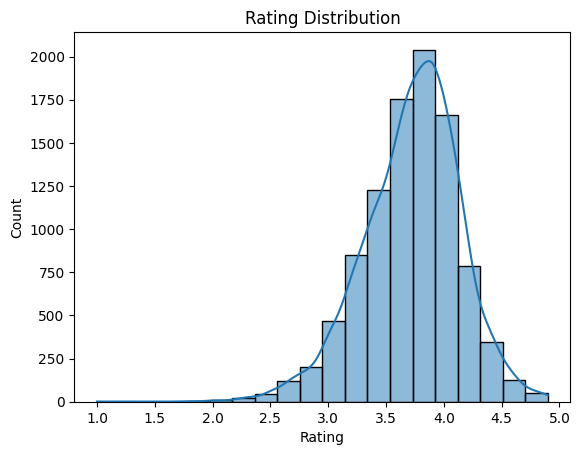

In [123]:
sns.histplot(df1['Rating'], bins=20, kde=True)
plt.title("Rating Distribution")
plt.show()

**# salary Distribution**

In [127]:
print(df1['Salaries'].head(20))
print(df1['Salaries'].dtype)

0     10.3L
1      7.1L
2      4.9L
3      6.1L
4      4.9L
5      1.5L
6      5.3L
7      3.9L
8      1.5L
9      2.9L
10     2.4L
11       1L
12    62.3k
13       1L
14     1.3L
15     1.6L
16    74.8k
17    24.9k
18       2L
19    49.4k
Name: Salaries, dtype: object
object


In [129]:
import numpy as np

def convert_salary(x):
    x = str(x).strip()

    # Missing values
    if x in ['--', '-', '', 'nan', 'None']:
        return np.nan

    # Lakhs
    elif x.endswith('L'):
        return float(x[:-1]) * 100000

    # Thousands
    elif x.endswith('k') or x.endswith('K'):
        return float(x[:-1]) * 1000

    # Normal numbers
    else:
        return float(x)

df1['Salaries'] = df1['Salaries'].apply(convert_salary)

In [130]:
df1['Salaries'].isnull().sum()

np.int64(12)

In [134]:
print(df1['Salaries'].dtype)

float64


In [132]:
print(df1['Salaries'].describe())

count    9.700000e+03
mean     2.899250e+03
std      1.903851e+04
min      2.000000e+00
25%      5.840000e+02
50%      9.340000e+02
75%      1.800000e+03
max      1.030000e+06
Name: Salaries, dtype: float64


In [133]:
print(df1['Salaries'].max())

1030000.0000000001


In [135]:
df1.sort_values(by='Salaries', ascending=False)[['Company Name', 'Salaries']].head(20)

,Company Name,Salaries
0,TCS,1030000.0
1,Accenture,710000.0
3,Cognizant,610000.0
6,Infosys,530000.0
2,Wipro,490000.0
4,Capgemini,490000.0
7,HCLTech,390000.0
9,Tech Mahindra,290000.0
22,Deloitte,270000.0
10,Genpact,240000.0


In [136]:
df1.sort_values(by='Salaries')[['Company Name', 'Salaries']].head(20)

,Company Name,Salaries
2086,India Private Driver,2.0
3877,TourTravelWorld.Com,2.0
575,Stellar Migration,2.0
9516,Graphura India Private Limited,3.0
9229,My Engineering Buddy,5.0
9536,Digiglobe Solutions,5.0
829,Royal Migration Solutions,5.0
1622,InternEzy,5.0
4723,Placementindia.com,5.0
6941,CollegePur,7.0


In [137]:
df['Salaries'].value_counts().head(30)

Salaries
1.1k    382
1.2k    349
1.3k    280
1k      240
1.4k    227
1.5k    211
1.6k    173
1.7k    166
1.8k    144
1.9k    121
2k      120
2.3k    103
2.1k     87
2.2k     80
2.4k     72
2.6k     67
3.1k     61
2.8k     59
2.9k     59
2.7k     56
2.5k     56
3.3k     53
3k       51
3.5k     43
3.2k     40
3.8k     39
3.7k     36
3.4k     34
4.6k     32
3.6k     31
Name: count, dtype: int64

In [138]:
df['Salaries'].value_counts().head(30)

Salaries
1.1k    382
1.2k    349
1.3k    280
1k      240
1.4k    227
1.5k    211
1.6k    173
1.7k    166
1.8k    144
1.9k    121
2k      120
2.3k    103
2.1k     87
2.2k     80
2.4k     72
2.6k     67
3.1k     61
2.8k     59
2.9k     59
2.7k     56
2.5k     56
3.3k     53
3k       51
3.5k     43
3.2k     40
3.8k     39
3.7k     36
3.4k     34
4.6k     32
3.6k     31
Name: count, dtype: int64

In [139]:
df['Salaries'].str.contains('L', na=False).sum()

np.int64(20)

In [140]:
df['Salaries'].str.contains('k', na=False).sum()

np.int64(4540)

In [141]:
df['Salaries'].str.fullmatch(r'\d+', na=False).sum()

np.int64(5140)

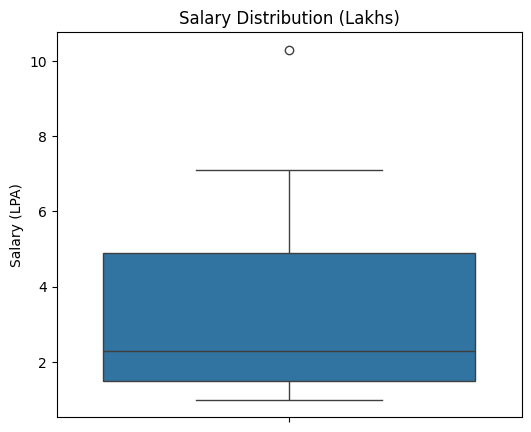

In [142]:
df_lakh = df[df['Salaries'].str.contains('L', na=False)].copy()

df_lakh['Salaries'] = (
    df_lakh['Salaries']
    .str.replace('L', '', regex=False)
    .astype(float)
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.boxplot(y=df_lakh['Salaries'])
plt.title("Salary Distribution (Lakhs)")
plt.ylabel("Salary (LPA)")
plt.show()

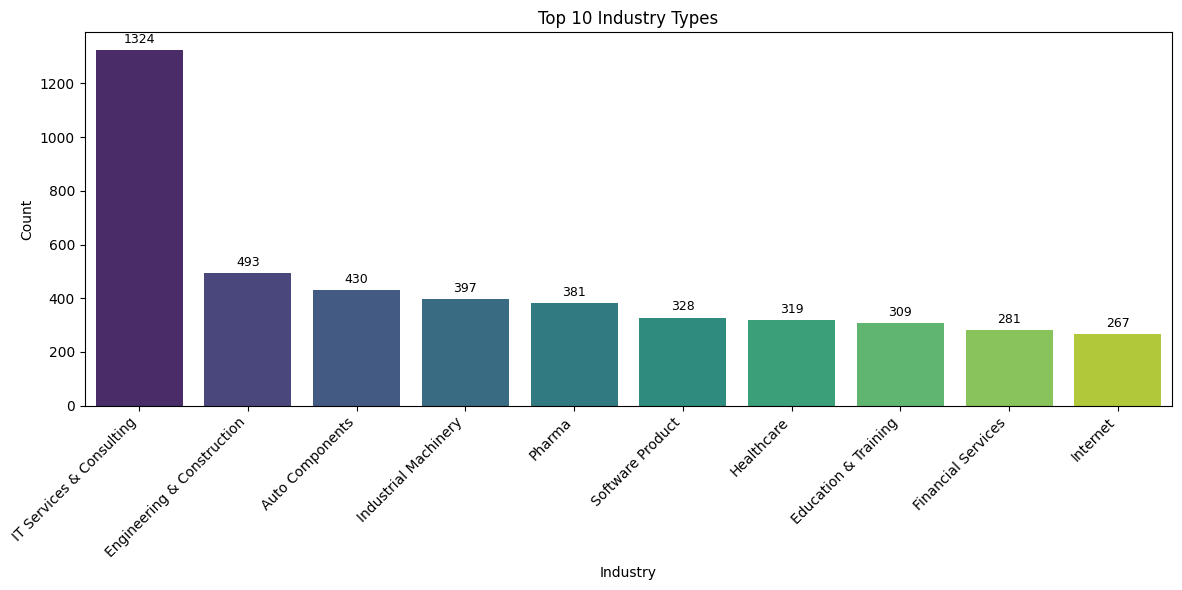

In [143]:
# Industry
counts = df1['Type'].value_counts().head(10)
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=counts.index,
    y=counts.values,
    palette='viridis'
)

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=9
    )
plt.title('Top 10 Industry Types')
plt.xlabel('Industry')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


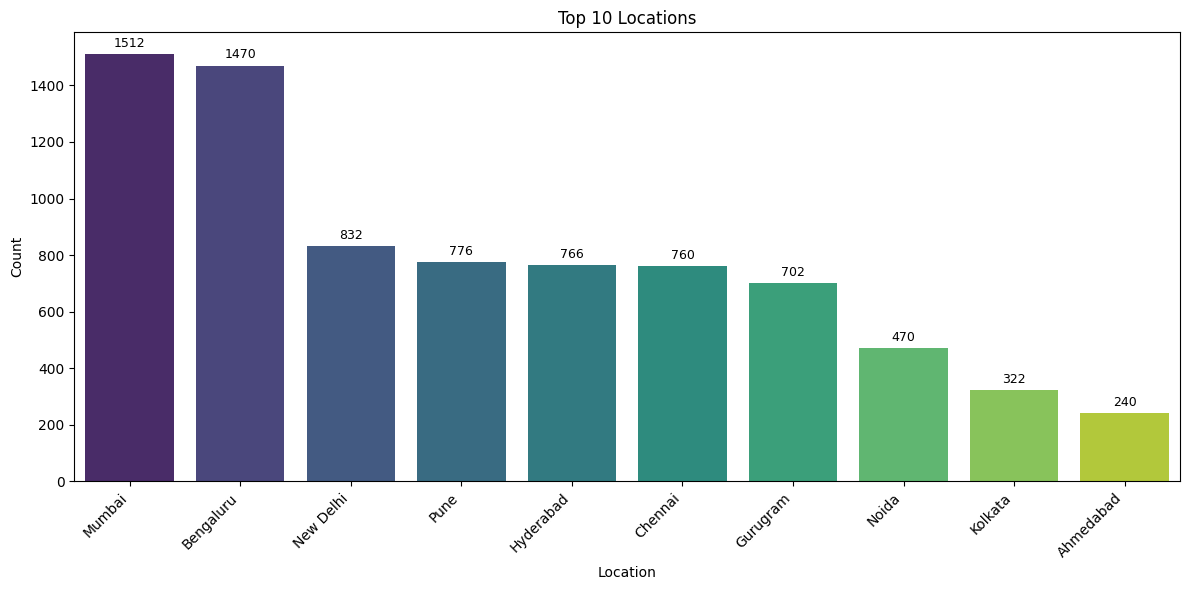

In [144]:
#Locations
counts = df1['Location'].value_counts().head(10)
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=counts.index,
    y=counts.values,
    palette='viridis'
)
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=9
    )
plt.title('Top 10 Locations')
plt.xlabel('Location')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# BIVARIATE ANALYSIS

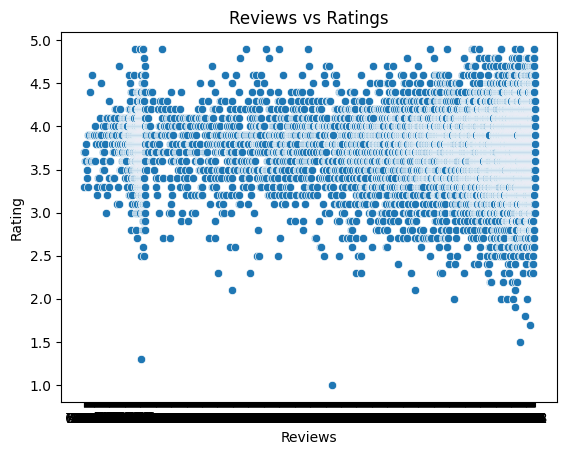

In [145]:
#Reviews VS Ratings
sns.scatterplot(data=df1, x='Reviews', y='Rating')
plt.title("Reviews vs Ratings")
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:.1f}'))
plt.show()

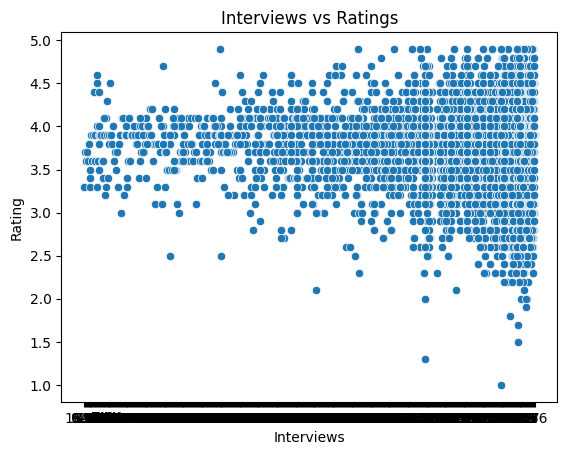

In [146]:
# Interviews VS Ratings
sns.scatterplot(data=df1, x='Interviews', y='Rating')
plt.title("Interviews vs Ratings")
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:.1f}'))
plt.show()

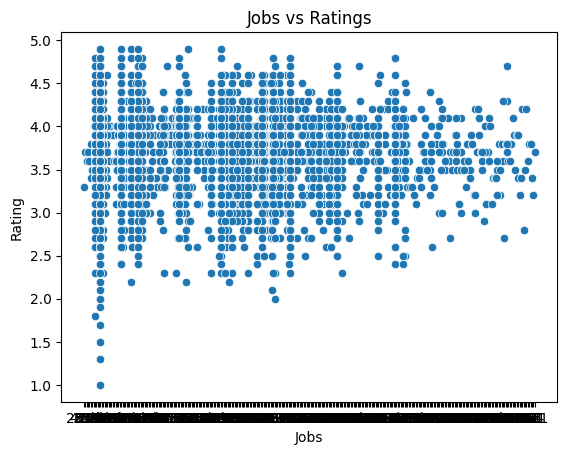

In [147]:
#Jobs VS Ratings
sns.scatterplot(data=df1, x='Jobs', y='Rating')
plt.title("Jobs vs Ratings")
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.1f}'))
plt.show()

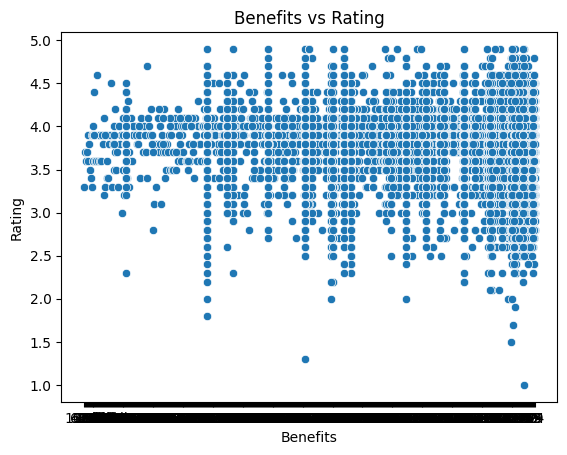

In [148]:
# Benefits VS Ratings
sns.scatterplot(data=df1, x='Benefits', y='Rating')
plt.title("Benefits vs Rating")
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.1f}'))
plt.show()

#  mixed approach

#  Top 10 Locations with Highest Salary

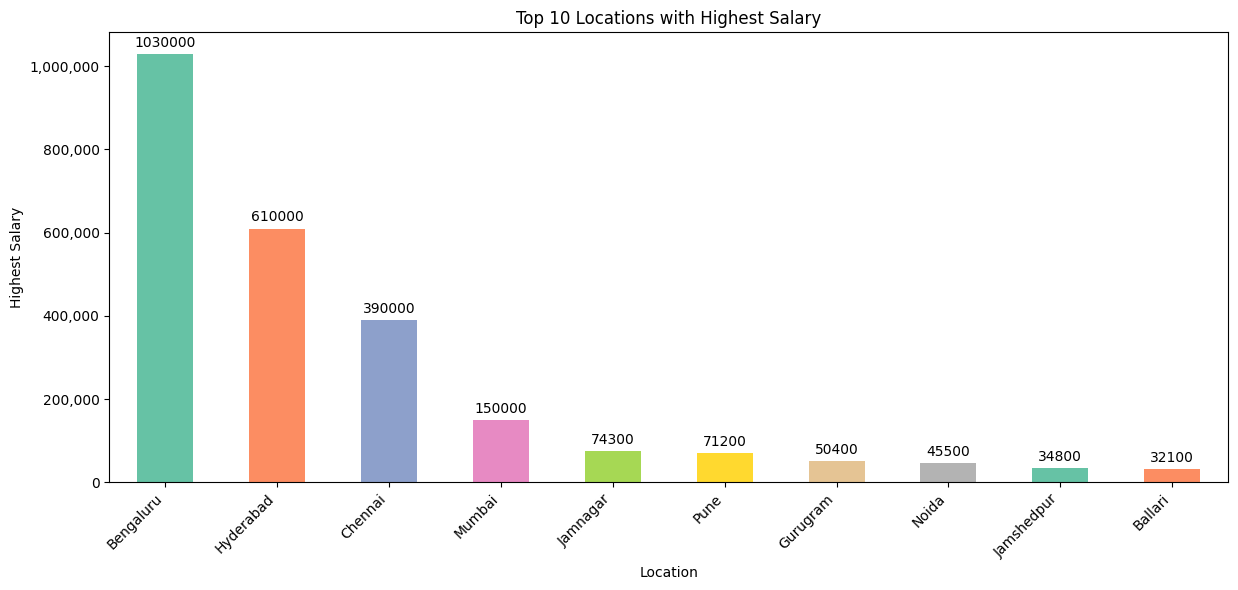

In [149]:
import matplotlib.pyplot as plt
import seaborn as sns

top10_locations = (
    df1.groupby('Location')['Salaries']
       .max()
       .sort_values(ascending=False)
       .head(10)
)

ax = top10_locations.plot(
    kind='bar',
    figsize=(12,6),
    color=sns.color_palette('Set2', len(top10_locations))
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.title('Top 10 Locations with Highest Salary')
plt.xlabel('Location')
plt.ylabel('Highest Salary')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()

# Top 10 Companies with Highest Salary

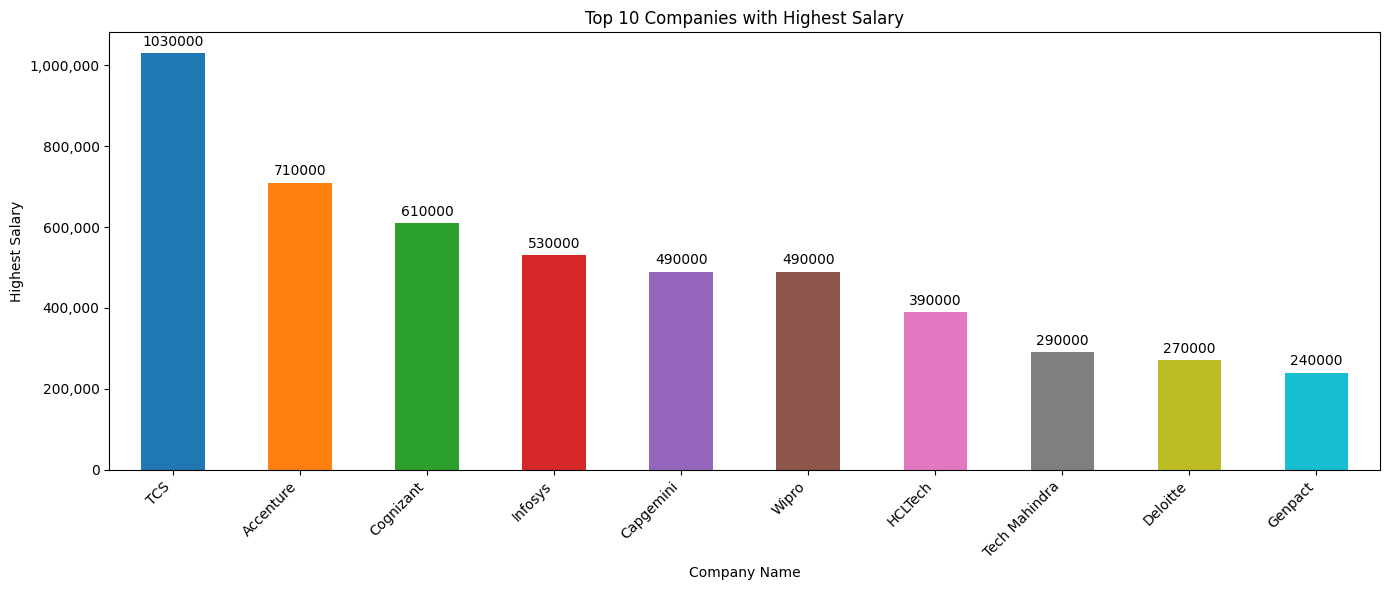

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns

top10_companies = (
    df1.groupby('Company Name')['Salaries']
       .max()
       .sort_values(ascending=False)
       .head(10)
)

ax = top10_companies.plot(
    kind='bar',
    figsize=(14,6),
    color=sns.color_palette('tab10', len(top10_companies))
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.title('Top 10 Companies with Highest Salary')
plt.xlabel('Company Name')
plt.ylabel('Highest Salary')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

# # Top 10 Industry Types by Average Salary

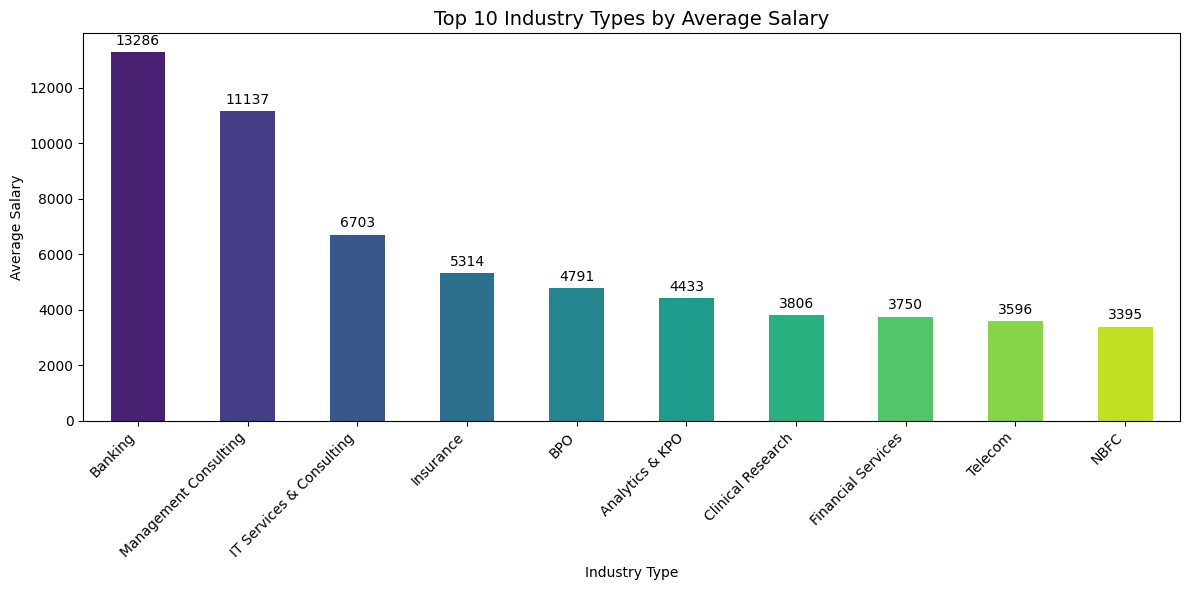

In [151]:
top10_salary_types = (
    df1.groupby('Type')['Salaries']
       .mean()
       .sort_values(ascending=False)
       .head(10)
)

plt.figure(figsize=(12,6))

ax = top10_salary_types.plot(
    kind='bar',
    color=sns.color_palette('viridis', len(top10_salary_types))
)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.title('Top 10 Industry Types by Average Salary', fontsize=14)
plt.xlabel('Industry Type')
plt.ylabel('Average Salary')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Top 10 Locations by Average Salary

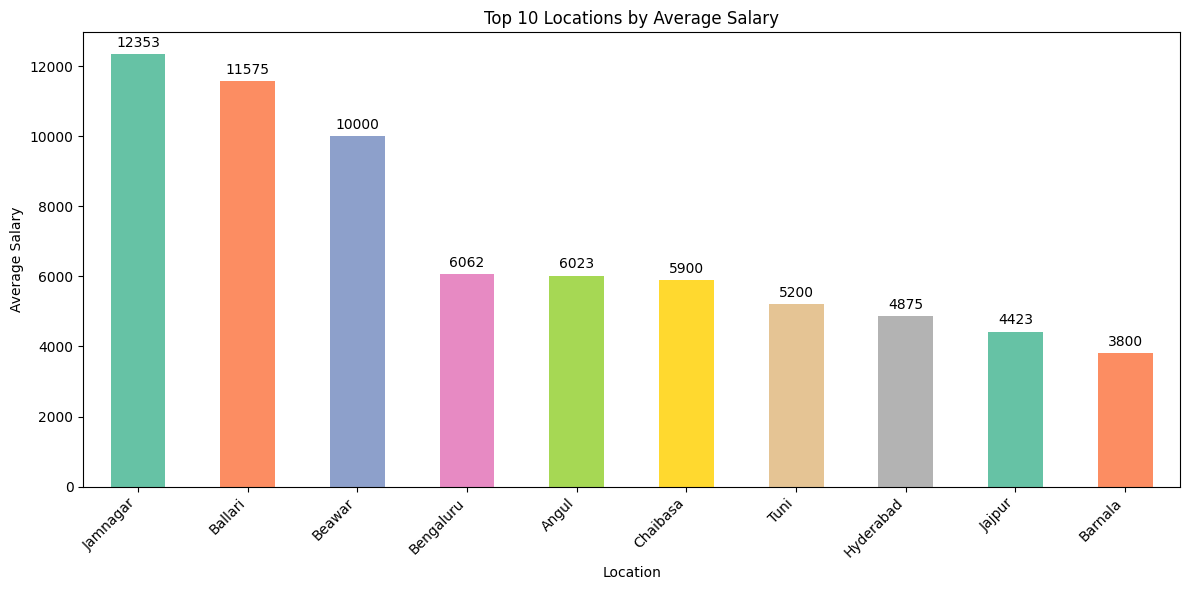

In [152]:
top10_locations = (
    df1.groupby('Location')['Salaries']
       .mean()
       .sort_values(ascending=False)
       .head(10)
)

plt.figure(figsize=(12,6))

ax = top10_locations.plot(
    kind='bar',
    color=sns.color_palette('Set2', len(top10_locations))
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.title('Top 10 Locations by Average Salary')
plt.xlabel('Location')
plt.ylabel('Average Salary')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

 # Top 10 Companies with Highest Reviews

In [154]:
print(df1['Reviews'].dtype)
print(df1['Reviews'].head())

object
0     1.2L
1    74.6k
2    65.9k
3    62.2k
4    54.3k
Name: Reviews, dtype: object


In [155]:
import numpy as np

def convert_count(x):
    x = str(x).strip()

    if x in ['--', '-', '', 'nan', 'None']:
        return np.nan
    elif x.endswith('L'):
        return float(x[:-1]) * 100000
    elif x.endswith('k') or x.endswith('K'):
        return float(x[:-1]) * 1000
    else:
        return float(x)

df1['Reviews'] = df1['Reviews'].apply(convert_count)

In [156]:
print(df1['Reviews'].dtype)

float64


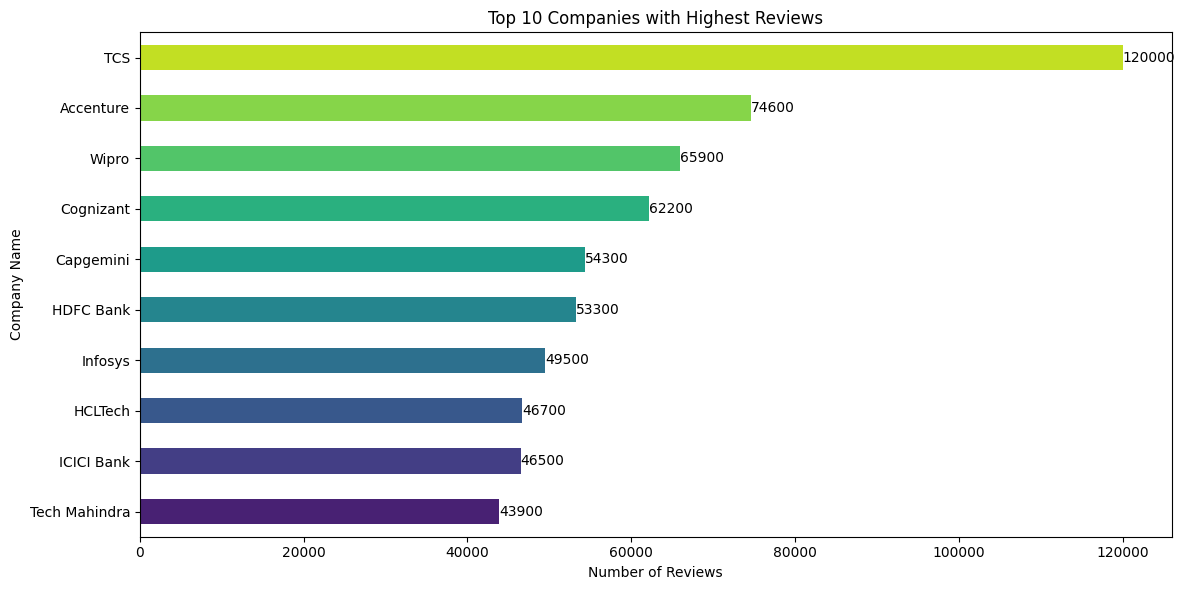

In [157]:
top10_reviews = (
    df1.groupby('Company Name')['Reviews']
       .max()
       .sort_values(ascending=False)
       .head(10)
       .sort_values()
)

ax = top10_reviews.plot(
    kind='barh',
    figsize=(12,6),
    color=sns.color_palette('viridis', len(top10_reviews))
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title('Top 10 Companies with Highest Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Company Name')
plt.tight_layout()
plt.show()

# # #Top 10 Locations by Total Interview Activity

In [159]:
print(df1['Interviews'].dtype)
print(df1['Interviews'].head())

object
0    11.4k
1     9.4k
2     6.9k
3     6.5k
4     5.6k
Name: Interviews, dtype: object


In [160]:
import numpy as np

def convert_count(x):
    x = str(x).strip()

    if x in ['--', '-', '', 'nan', 'None']:
        return np.nan
    elif x.endswith('L'):
        return float(x[:-1]) * 100000
    elif x.endswith(('k', 'K')):
        return float(x[:-1]) * 1000
    else:
        return float(x)

df1['Interviews'] = df1['Interviews'].apply(convert_count)

In [161]:
print(df1['Interviews'].dtype)

float64


In [162]:
import numpy as np

cols = ['Reviews', 'Salaries', 'Interviews', 'Jobs', 'Benefits']

def convert_count(x):
    x = str(x).strip()

    if x in ['--', '-', '', 'nan', 'None']:
        return np.nan
    elif x.endswith('L'):
        return float(x[:-1]) * 100000
    elif x.endswith(('k', 'K')):
        return float(x[:-1]) * 1000
    else:
        return float(x)

for col in cols:
    df1[col] = df1[col].apply(convert_count)

In [163]:
print(df1[cols].dtypes)

Reviews       float64
Salaries      float64
Interviews    float64
Jobs          float64
Benefits      float64
dtype: object


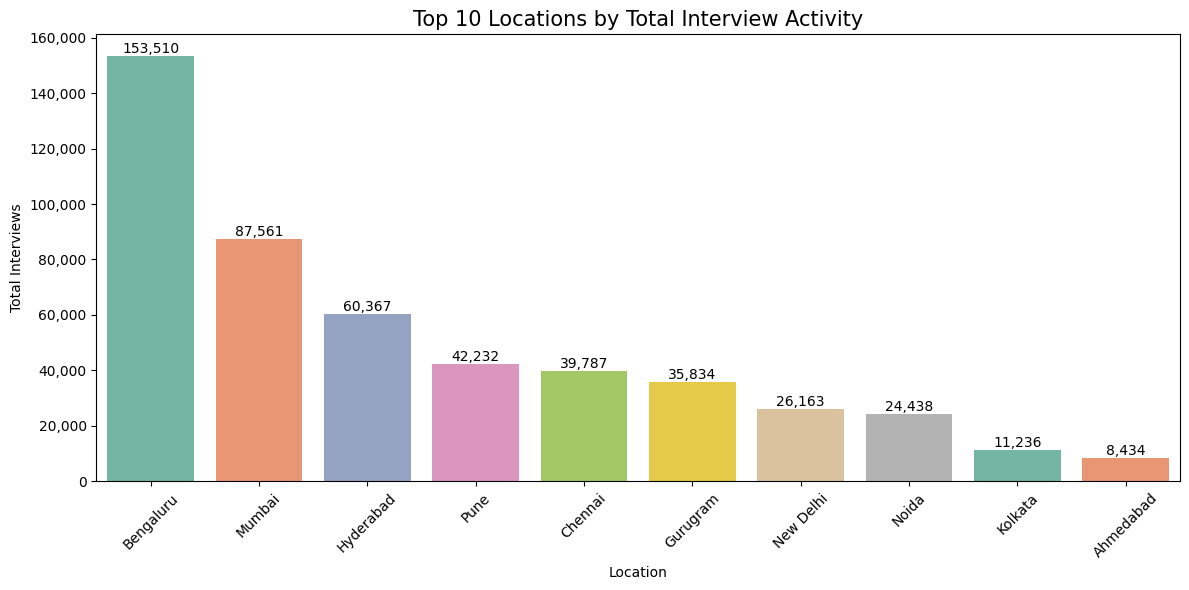

In [164]:
# Top 10 locations by interviews
top10_locations = (
    df1.groupby('Location')['Interviews']
       .sum()
       .sort_values(ascending=False)
       .head(10)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top10_locations.index,
    y=top10_locations.values,
    palette='Set2'
)

# Labels on bars
for i, value in enumerate(top10_locations.values):
    ax.text(i, value, f'{value:,.0f}',
            ha='center', va='bottom', fontsize=10)

plt.title("Top 10 Locations by Total Interview Activity", fontsize=15)
plt.xlabel("Location")
plt.ylabel("Total Interviews")

plt.xticks(rotation=45)

# Format y-axis
ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)

plt.tight_layout()
plt.show()

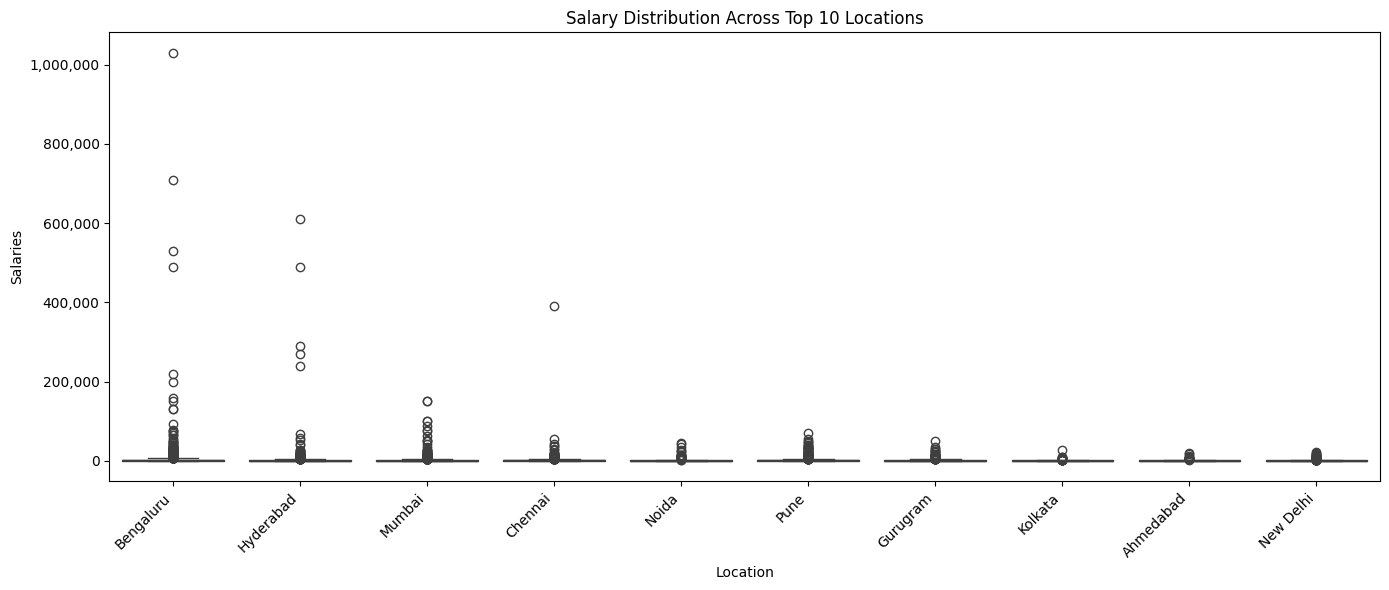

In [165]:
# Salary Distribution Across Top 10 Locations
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 locations by total salary count
top10_locations = (
    df1.groupby('Location')['Salaries']
       .sum()
       .sort_values(ascending=False)
       .head(10)
       .index
)

# Filter data for top 10 locations
df_top10 = df1[df1['Location'].isin(top10_locations)]

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df_top10,
    x='Location',
    y='Salaries'
)

plt.title('Salary Distribution Across Top 10 Locations')
plt.xlabel('Location')
plt.ylabel('Salaries')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

# MULTIVARIATE ANALYSIS

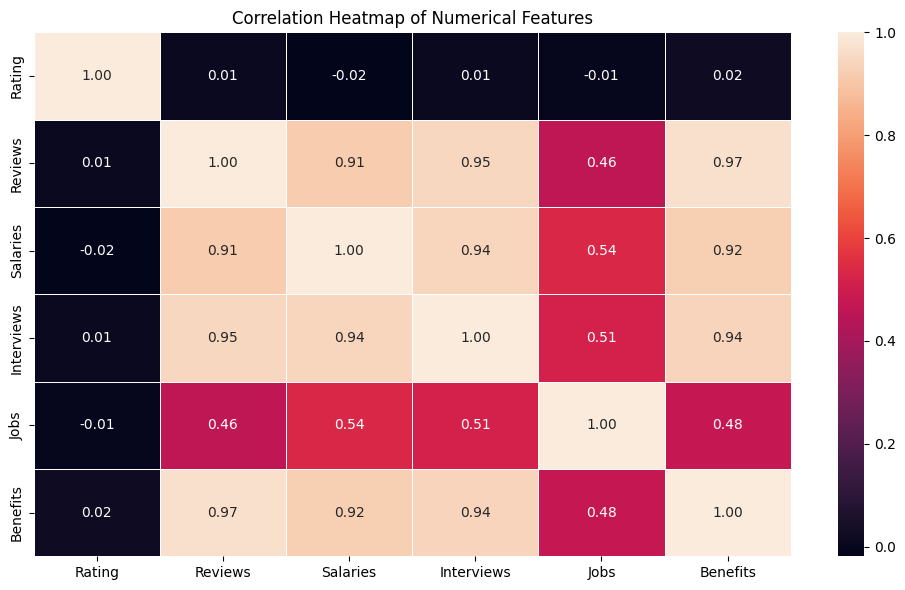

In [166]:
# Correlation Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

corr_matrix = df1[['Rating','Reviews','Salaries',
                   'Interviews','Jobs','Benefits']].corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    # cmap='YlGnBu',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

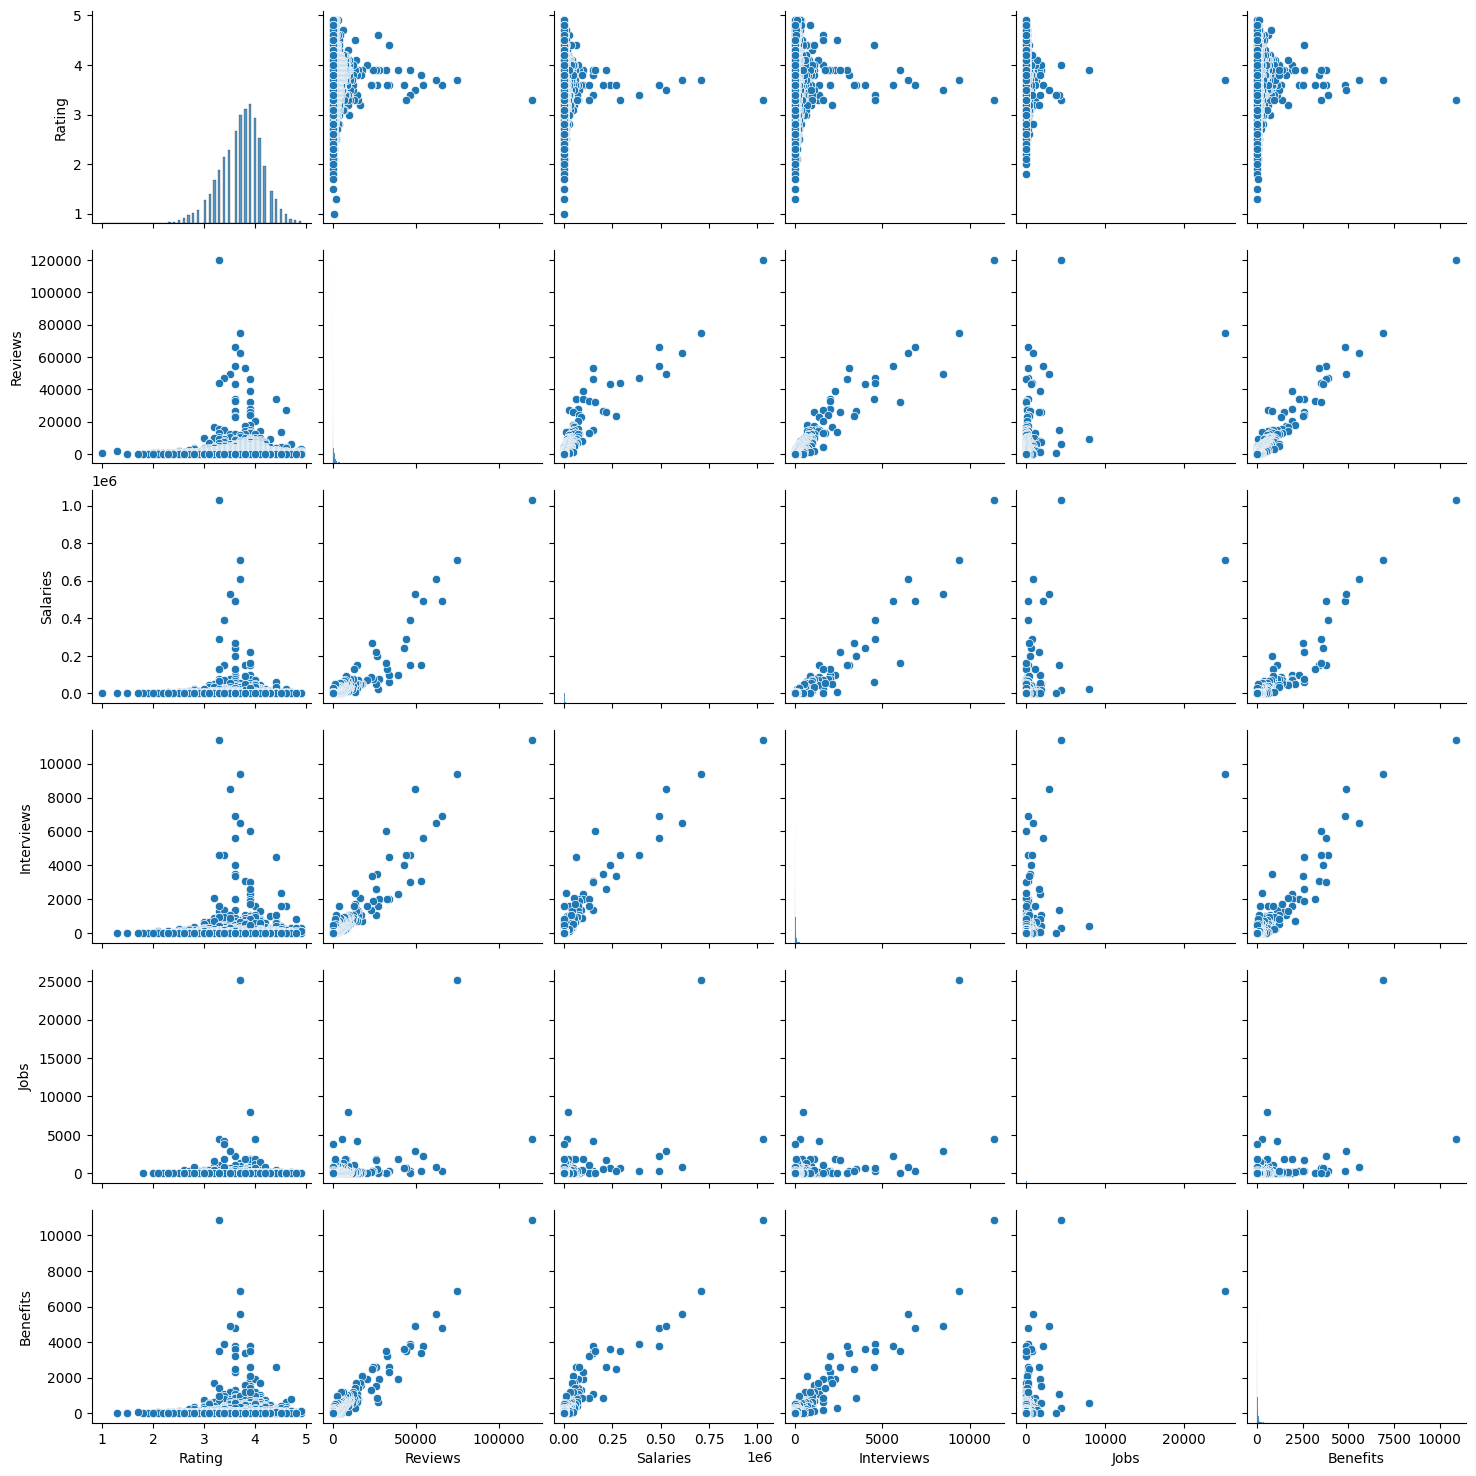

In [167]:
sns.pairplot(df1[['Rating','Reviews','Salaries','Interviews','Jobs','Benefits']])
plt.show()